In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder


In [5]:
# Load the dataset
df = pd.read_csv("iris.csv")

# Display first few rows
print(df.head())


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [7]:
 # Encode the target variable (species) into numeric labels
label_encoder = LabelEncoder()
df['species'] = label_encoder.fit_transform(df['species'])

# Select features (X) and target variable (y)
X = df.drop(columns=['species'])  # Features
y = df['species']  # Target variable

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
# Create Naïve Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()[:4]  # Extract values from confusion matrix

# Compute additional metrics
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0

# Print results
print(f"Confusion Matrix:\n{cm}")
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")
print(f"Accuracy: {accuracy:.2f}")
print(f"Error Rate: {error_rate:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
True Positives (TP): 0
False Positives (FP): 0
True Negatives (TN): 10
False Negatives (FN): 0
Accuracy: 1.00
Error Rate: 0.00
Precision: 0.00
Recall: 0.00


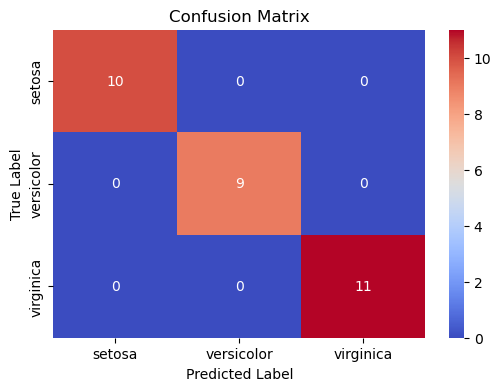

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
